In [78]:
import json
import pickle
import os
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def calculate_eta(vi, wi, theta, V):
    rho_v = theta[vi, :]          # ρ_v = θ_v
    alpha_w = theta[wi + V, :]    # α_w = θ_{V + w}
    eta = rho_v.dot(alpha_w)      # η = ρ_v^T α_w
    return eta

def calculate_p(vi, wi, theta, V):
    eta = calculate_eta(vi, wi, theta, V)
    return sigmoid(eta)

def load_fit(size, save_dir):
    filename = os.path.join(save_dir, f'stan_fit_{size}.pkl')
    with open(filename, 'rb') as f:
        fit = pickle.load(f)
    return fit

def calculate_rmse(theta_samples, true_theta, vocabulary):
    V = len(vocabulary)
    
    p_true = []
    p_avg = []

    for word1 in vocabulary:
        for word2 in vocabulary:
            vi = vocabulary[word1]
            wi = vocabulary[word2]
            p_true.append(calculate_p(vi, wi, true_theta, V))

            p_samples = [calculate_p(vi, wi, theta, V) for theta in theta_samples]
            p_avg.append(np.mean(p_samples))
    
    p_true = np.array(p_true)
    p_avg = np.array(p_avg)
    
    rmse = np.sqrt(np.mean((p_true - p_avg) ** 2))
    return rmse


def extract_word_and_context_vectors_vi2(fit, vocabulary, D=2):
    """
    VI helper: extracts the word and context vectors from the variational parameters.
    """
    variational_samples_pd = fit.variational_params_pd

    # exclude the first three columns (lp__, log_p__, log_g__) and context_vectors_raw
    relevant_params = np.delete(variational_samples_pd, np.s_[3:3+(len(vocabulary)-D)*D], axis=1)
    
    num_samples = relevant_params.shape[0]
    word_vectors = np.zeros((num_samples, len(vocabulary), D))
    context_vectors = np.zeros((num_samples, len(vocabulary), D))
    
    for d in range(D):
        for n in range(len(vocabulary)):
            word_vectors[:, n, d] = relevant_params[:, n + d * len(vocabulary)]
            context_vectors[:, n, d] = relevant_params[:, len(vocabulary) * D + n + d * len(vocabulary)]
    
    return word_vectors, context_vectors


def extract_word_and_context_vectors_vi(fit, vocabulary, D=2):
    """
    VI helper: extracts the word and context vectors from the variational parameters.
    """
    variational_samples_pd = fit.variational_sample_pd

    # Drop the first three columns: 'lp__', 'log_p__', 'log_g__'
    relevant_params = variational_samples_pd.drop(columns=['lp__','log_p__','log_g__'])

    # Drop columns related to 'context_vectors_raw'
    raw_context_columns = [col for col in relevant_params.columns if 'context_vectors_raw' in col]
    relevant_params = relevant_params.drop(columns=raw_context_columns)

    num_samples = relevant_params.shape[0]
    V = len(vocabulary)
    
    word_vectors = np.zeros((num_samples, V, D))
    context_vectors = np.zeros((num_samples, V, D))
    
    for d in range(D):
        for n in range(V):
            word_vectors[:, n, d] = relevant_params[f'word_vectors[{n+1},{d+1}]'].values
            context_vectors[:, n, d] = relevant_params[f'context_vectors[{n+1},{d+1}]'].values
    
    word_vectors = np.transpose(word_vectors, (1, 2, 0))  # dim = (V, D, num_samples)  - reshape to match hmc output.
    context_vectors = np.transpose(context_vectors, (1, 2, 0)) 
    

    return word_vectors, context_vectors

# Convergence Plots

Size: 100, RMSE: 0.11995932994303174
Size: 200, RMSE: 0.10752820813197919
Size: 500, RMSE: 0.10129990134379706
Size: 1000, RMSE: 0.09149425214425017
Size: 5000, RMSE: 0.05151884407003003
Size: 20000, RMSE: 0.04430441873454137
Size: 50000, RMSE: 0.03708377524666578
Size: 100000, RMSE: 0.02432486448855743


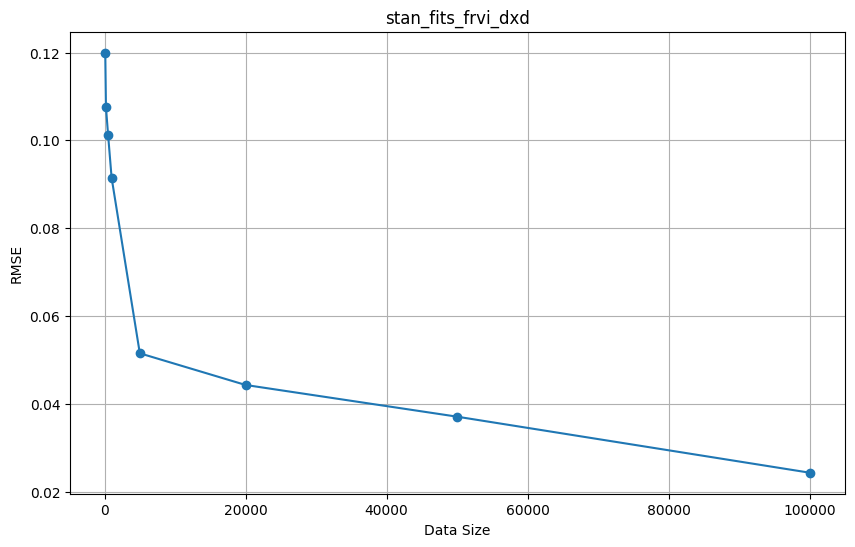

In [82]:

saved_fits_dir = "stan_fits_frvi_dxd"#"stan_fits_mfvi_dxd"#"stan_fits_dxdfixmap" "stan_fit_nofix" "stan_fits_frvi_dxd"
inference_method = 'vi'
sizes = [100, 200, 500, 1000, 5000, 20000, 50000, 100000]

# -- true parameters --
with open('100k_v10_d2_.json') as f:
    data = json.load(f)
true_theta = np.array(data['theta'])
vocabulary = data['vocabulary']

rmse_scores = []

for size in sizes:
    fit = load_fit(size, saved_fits_dir)

    if inference_method == 'hmc':
        estimated_word_vectors = fit['word_vectors']
        estimated_context_vectors = fit['context_vectors']
        num_samples = estimated_word_vectors.shape[2]
            
    elif inference_method == 'vi':
        #variational_params = fit.variational_sample
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit, vocabulary)
        num_samples = estimated_word_vectors.shape[2]

    theta_samples = []
    for i in range(num_samples):
        word_vectors = estimated_word_vectors[:, :, i]
        context_vectors = estimated_context_vectors[:, :, i]
        theta = np.vstack((word_vectors, context_vectors))
        theta_samples.append(theta)

        
    rmse = calculate_rmse(theta_samples, true_theta, vocabulary)
    rmse_scores.append(rmse)
    print(f"Size: {size}, RMSE: {rmse}")

# Plot RMSE vs. Size
plt.figure(figsize=(10, 6))
plt.plot(sizes, rmse_scores, marker='o')
plt.xlabel('Data Size')
plt.ylabel('RMSE')
plt.title(f'{saved_fits_dir}')
#plt.xscale('log')
plt.grid(True)
plt.show()


In [77]:
np.shape(estimated_word_vectors)

(1000, 10, 2)

# Word Pair Convergence

In [63]:
def credible_interval(samples, confidence=0.90):
    lower_bound = np.percentile(samples, (1 - confidence) / 2 * 100)
    upper_bound = np.percentile(samples, (1 + confidence) / 2 * 100)
    return lower_bound, upper_bound

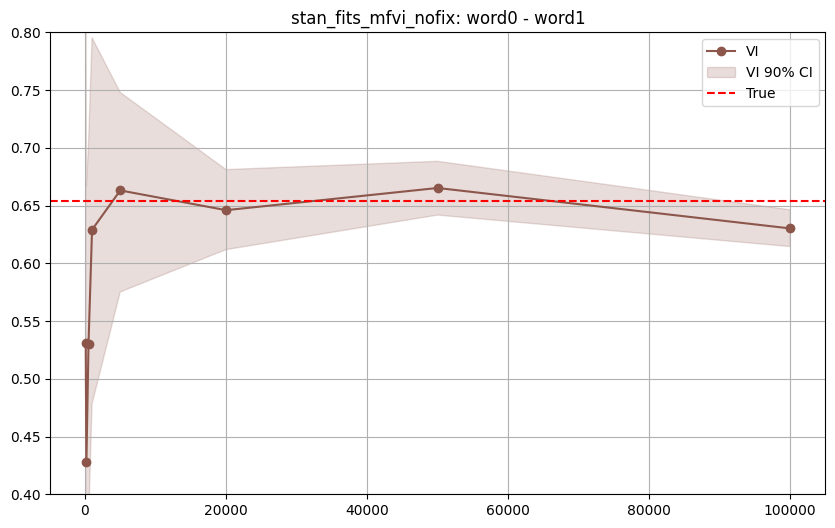

In [167]:
word1 = "word0"
word2 = "word1"


sizes = [100, 200, 500, 1000, 5000, 20000, 50000, 100000]
saved_fits_dir = "stan_fits_mfvi_nofix"#"stan_fits_dxdfixmap"
inference_method = 'vi'


with open('100k_v10_d2_.json') as f:
    data = json.load(f)

true_theta = np.array(data['theta'])
vocabulary = data['vocabulary']

true_p = calculate_p(vocabulary[word1], vocabulary[word2], true_theta, len(vocabulary))

p_means = []
credible_intervals = []

for size in sizes:
    fit = load_fit(size, saved_fits_dir)

    if inference_method == 'hmc':
        estimated_word_vectors = fit['word_vectors']
        estimated_context_vectors = fit['context_vectors']
        num_samples = estimated_word_vectors.shape[2]
    elif inference_method == 'vi':
        estimated_word_vectors, estimated_context_vectors = extract_word_and_context_vectors_vi(fit, vocabulary)
        num_samples = estimated_word_vectors.shape[2]

    theta_samples = []
    for i in range(num_samples):
        word_vectors = estimated_word_vectors[:, :, i]
        context_vectors = estimated_context_vectors[:, :, i]
        theta = np.vstack((word_vectors, context_vectors))
        theta_samples.append(theta)

    vi = vocabulary[word1]
    wi = vocabulary[word2]
    eta_samples = [calculate_p(vi, wi, theta, len(vocabulary)) for theta in theta_samples]

    mean_p = np.mean(eta_samples)
    lower_ci, upper_ci = credible_interval(eta_samples)

    p_means.append(mean_p)
    credible_intervals.append((lower_ci, upper_ci))

    #print(f"Size {size}: Mean p = {mean_p}, 90% CI = ({lower_ci}, {upper_ci})")

p_means = np.array(p_means)
credible_intervals = np.array(credible_intervals)

plt.figure(figsize=(10, 6))
plt.ylim([0.4, 0.8])
plt.plot(sizes, p_means, marker='o', linestyle='-', label='VI', color='tab:brown')
plt.fill_between(sizes, credible_intervals[:, 0], credible_intervals[:, 1], color='tab:brown', alpha=0.2, label='VI 90% CI')
plt.axhline(y=true_p, color='r', linestyle='--', label='True')
#plt.xlabel('Data Size')
#plt.ylabel('Co-occurrence probability')
plt.title(f'{saved_fits_dir}: {word1} - {word2}')
plt.legend()
plt.grid(True)
plt.show()

# "Donut" Plot

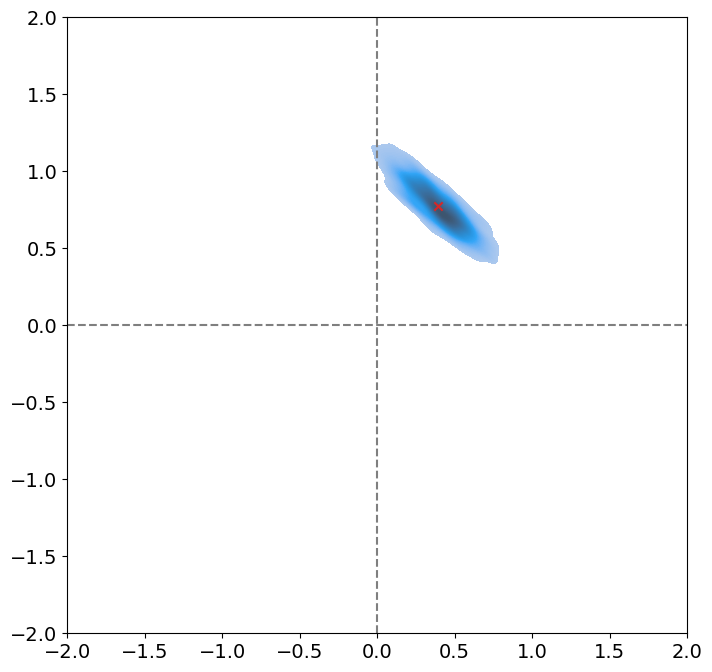

In [176]:
import seaborn as sns
import pandas as pd

word_index = 0

with open('100k_v10_d2_.json') as f:
    data = json.load(f)

vocabulary = data['vocabulary']

# --  specify fit ---
inference_method = 'hmc' 
size = 100000
saved_fits_dir = "stan_fits_dxdfixmap" #"stan_fits_mfvi_dxd" #"stan_fits_dxdfixmap" stan_fit_nofix
fit = load_fit(size, saved_fits_dir)

if inference_method == 'hmc':
    word_vectors_samples = fit['word_vectors']
    #context_vectors_samples = fit['context_vectors']
elif inference_method == 'vi':
    word_vectors_samples, _ = extract_word_and_context_vectors_vi(fit, vocabulary)
# ----

#def plot_posterior(word_index, word_vectors_samples, vocabulary):
word_samples = word_vectors_samples[word_index]

data = {
    'Dim 1': word_samples[0, :],
    'Dim 2': word_samples[1, :],
}
df = pd.DataFrame(data)

plt.figure(figsize=(8, 8))
sns.kdeplot(x='Dim 1', y='Dim 2', data=df, fill=True, thresh=0.05, levels=100) # cmap='Blues'
#sns.jointplot(x='Dim 1', y='Dim 2', data=df, kind='kde', fill=True)

#plt.title(f"{saved_fits_dir} post samples for '{list(vocabulary.keys())[word_index]}'")
plt.scatter([np.mean(word_samples[0, :])], [np.mean(word_samples[1, :])], marker='x', color='tab:red')
plt.axhline(y=0, color='tab:gray', ls='--')
plt.axvline(x=0, color='tab:gray', ls='--')
plt.xlim([-2, 2])
plt.ylim([-2, 2])


plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel('')
plt.ylabel('')


plt.savefig(f'figs/donut_{saved_fits_dir}_wordidx{word_index}.pdf')

plt.show()



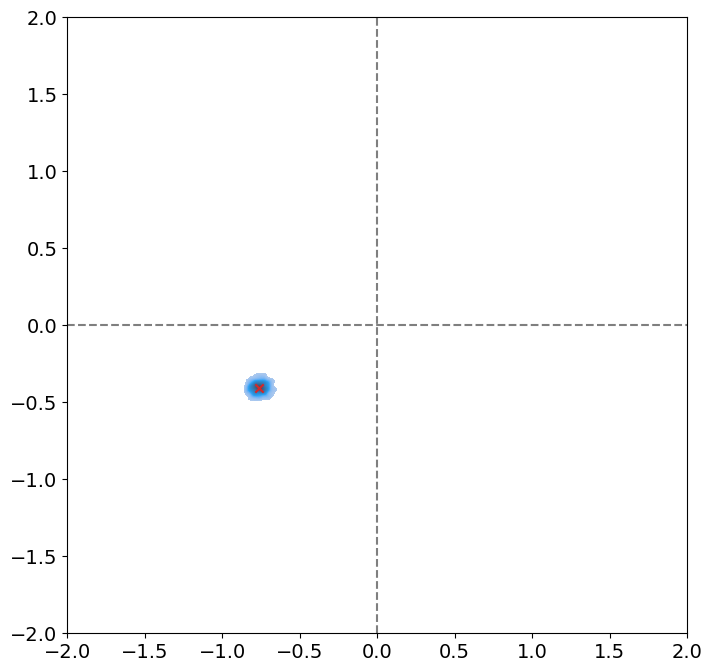

In [178]:
import seaborn as sns
import pandas as pd


with open('100k_v10_d2_.json') as f:
    data = json.load(f)

vocabulary = data['vocabulary']

# --  specify fit ---
inference_method = 'vi' 
saved_fits_dir = "stan_fits_mfvi_nofix" #"stan_fits_mfvi_dxd" #"stan_fits_dxdfixmap" #stan_fits_mfvi_nofix
fit = load_fit(size, saved_fits_dir)

if inference_method == 'hmc':
    word_vectors_samples = fit['word_vectors']
    #context_vectors_samples = fit['context_vectors']
elif inference_method == 'vi':
    word_vectors_samples, _ = extract_word_and_context_vectors_vi(fit, vocabulary)
# ----

#def plot_posterior(word_index, word_vectors_samples, vocabulary):
word_samples = word_vectors_samples[word_index]

data = {
    'Dim 1': word_samples[0, :],
    'Dim 2': word_samples[1, :],
}
df = pd.DataFrame(data)

plt.figure(figsize=(8, 8))
sns.kdeplot(x='Dim 1', y='Dim 2', data=df, fill=True, thresh=0.05, levels=100) # cmap='Blues'
#sns.jointplot(x='Dim 1', y='Dim 2', data=df, kind='kde', fill=True)

#plt.title(f"{saved_fits_dir} post samples for '{list(vocabulary.keys())[word_index]}'")
plt.scatter([np.mean(word_samples[0, :])], [np.mean(word_samples[1, :])], marker='x', color='tab:red')
plt.axhline(y=0, color='tab:gray', ls='--')
plt.axvline(x=0, color='tab:gray', ls='--')
plt.xlim([-2, 2])
plt.ylim([-2, 2])


plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel('')
plt.ylabel('')


plt.savefig(f'figs/donut_{saved_fits_dir}_wordidx{word_index}.pdf')

plt.show()



plt.show()